<a href="https://colab.research.google.com/github/guebin/DL2026/blob/master/posts/Prj2.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" style="text-align: left"></a>

In [5]:
import urllib.request, zipfile
import torch
import torchvision
import matplotlib.pyplot as plt

In [6]:
for name, url in {
    "rps.zip":          "https://storage.googleapis.com/learning-datasets/rps.zip",
    "rps-test-set.zip": "https://storage.googleapis.com/learning-datasets/rps-test-set.zip",
}.items():
    urllib.request.urlretrieve(url, name)
    with zipfile.ZipFile(name) as z:
        z.extractall(".")

train_dataset = torchvision.datasets.ImageFolder(root="rps", transform=torchvision.transforms.ToTensor())
test_dataset  = torchvision.datasets.ImageFolder(root="rps-test-set", transform=torchvision.transforms.ToTensor())
train_dataset, valid_dataset = torch.utils.data.random_split(train_dataset, [0.8, 0.2])

위의 자료는 **Rock-Paper-Scissors(가위바위보)** 데이터셋으로, 손모양(가위/바위/보)을 찍은 이미지로 이루어진 3-클래스 이미지분류 데이터셋이다.

-  출처: Laurence Moroney, *Rock-Paper-Scissors Dataset* (<https://laurencemoroney.com/datasets.html>).

class index는 다음과 같다.

```Python
{'paper': 0, 'rock': 1, 'scissors': 2}
```

각 클래스의 대표 이미지를 시각화하면 다음과 같다.

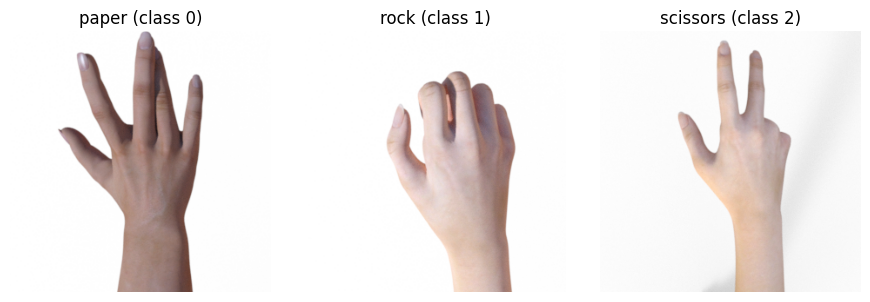

In [7]:
#| code-fold: true
#| code-summary: "시각화 코드 보기"
disp = torchvision.datasets.ImageFolder(root="rps")  # 시각화용 (transform 없이 PIL 이미지)
fig, ax = plt.subplots(1, 3, figsize=(9, 3))
for i, cls in enumerate(disp.classes):
    idx = disp.targets.index(i)            # 해당 클래스의 첫 샘플
    ax[i].imshow(disp[idx][0])
    ax[i].set_title(f"{cls} (class {i})")
    ax[i].axis("off")
plt.tight_layout()

`(1)` **직접 설계한 CNN**으로 가위/바위/보 3개의 클래스를 분류하는 네트워크를 학습하라.

> **`test accuracy` 가 95% 이상이면 정답으로 인정함.**

`(2)` 사전학습된 `resnet18` 으로 가위/바위/보 3개의 클래스를 분류하는 네트워크를 학습하라.

> **`test accuracy` 가 95% 이상이면 정답으로 인정함.**